In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import torch
import torch.nn as nn
import h5py
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm


warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.dpi'] = 200 # plots quality


path='/content/drive/Shareddrives/XAI Project Shared Drive'

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


# loading and unzipin the data (**SKIIIIP**)




In [ ]:
# !unzip -q "/content/drive/MyDrive/XAI_Project/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip" -d /content/ptb_xl_local/

In [ ]:
# path = '/content/ptb_xl_local/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'

# csv_path = os.path.join(path, 'ptbxl_database.csv')
# df_ptbxl = pd.read_csv(csv_path, index_col='ecg_id')

# df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

# def load_raw_data(df, sampling_rate, path):
#     if sampling_rate == 100:
#         records = [wfdb.rdsamp(os.path.join(path, f)) for f in df['filename_lr']]
#     else:
#         records = [wfdb.rdsamp(os.path.join(path, f)) for f in df['filename_hr']]

#     data = np.array([signal for signal, meta in records])
#     return data

# X = load_raw_data(df_ptbxl, sampling_rate=100, path=path)
# print(f"Signal array shape: {X.shape}")

In [ ]:
# print("Saving X array to Drive...")
# np.save('/content/drive/MyDrive/XAI_Project/X_100hz.npy', X)

# print("Saving metadata to Drive...")
# df_ptbxl.to_csv('/content/drive/MyDrive/XAI_Project/ptbxl_processed_metadata.csv')



In [ ]:
!pip install "numpy<2" shap --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is 

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 112.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user


In [ ]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os

ModuleNotFoundError: No module named 'wfdb'

# Starting Point

In [ ]:
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [ ]:
print(len(df_ptbxl['patient_id'].unique()), "patients")

18869 patients


# EDA

In [ ]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

print("\nSample of Superclass Targets:")
display(df_ptbxl[['diagnostic_superclass'] + superclasses].head())


Sample of Superclass Targets:


,diagnostic_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0


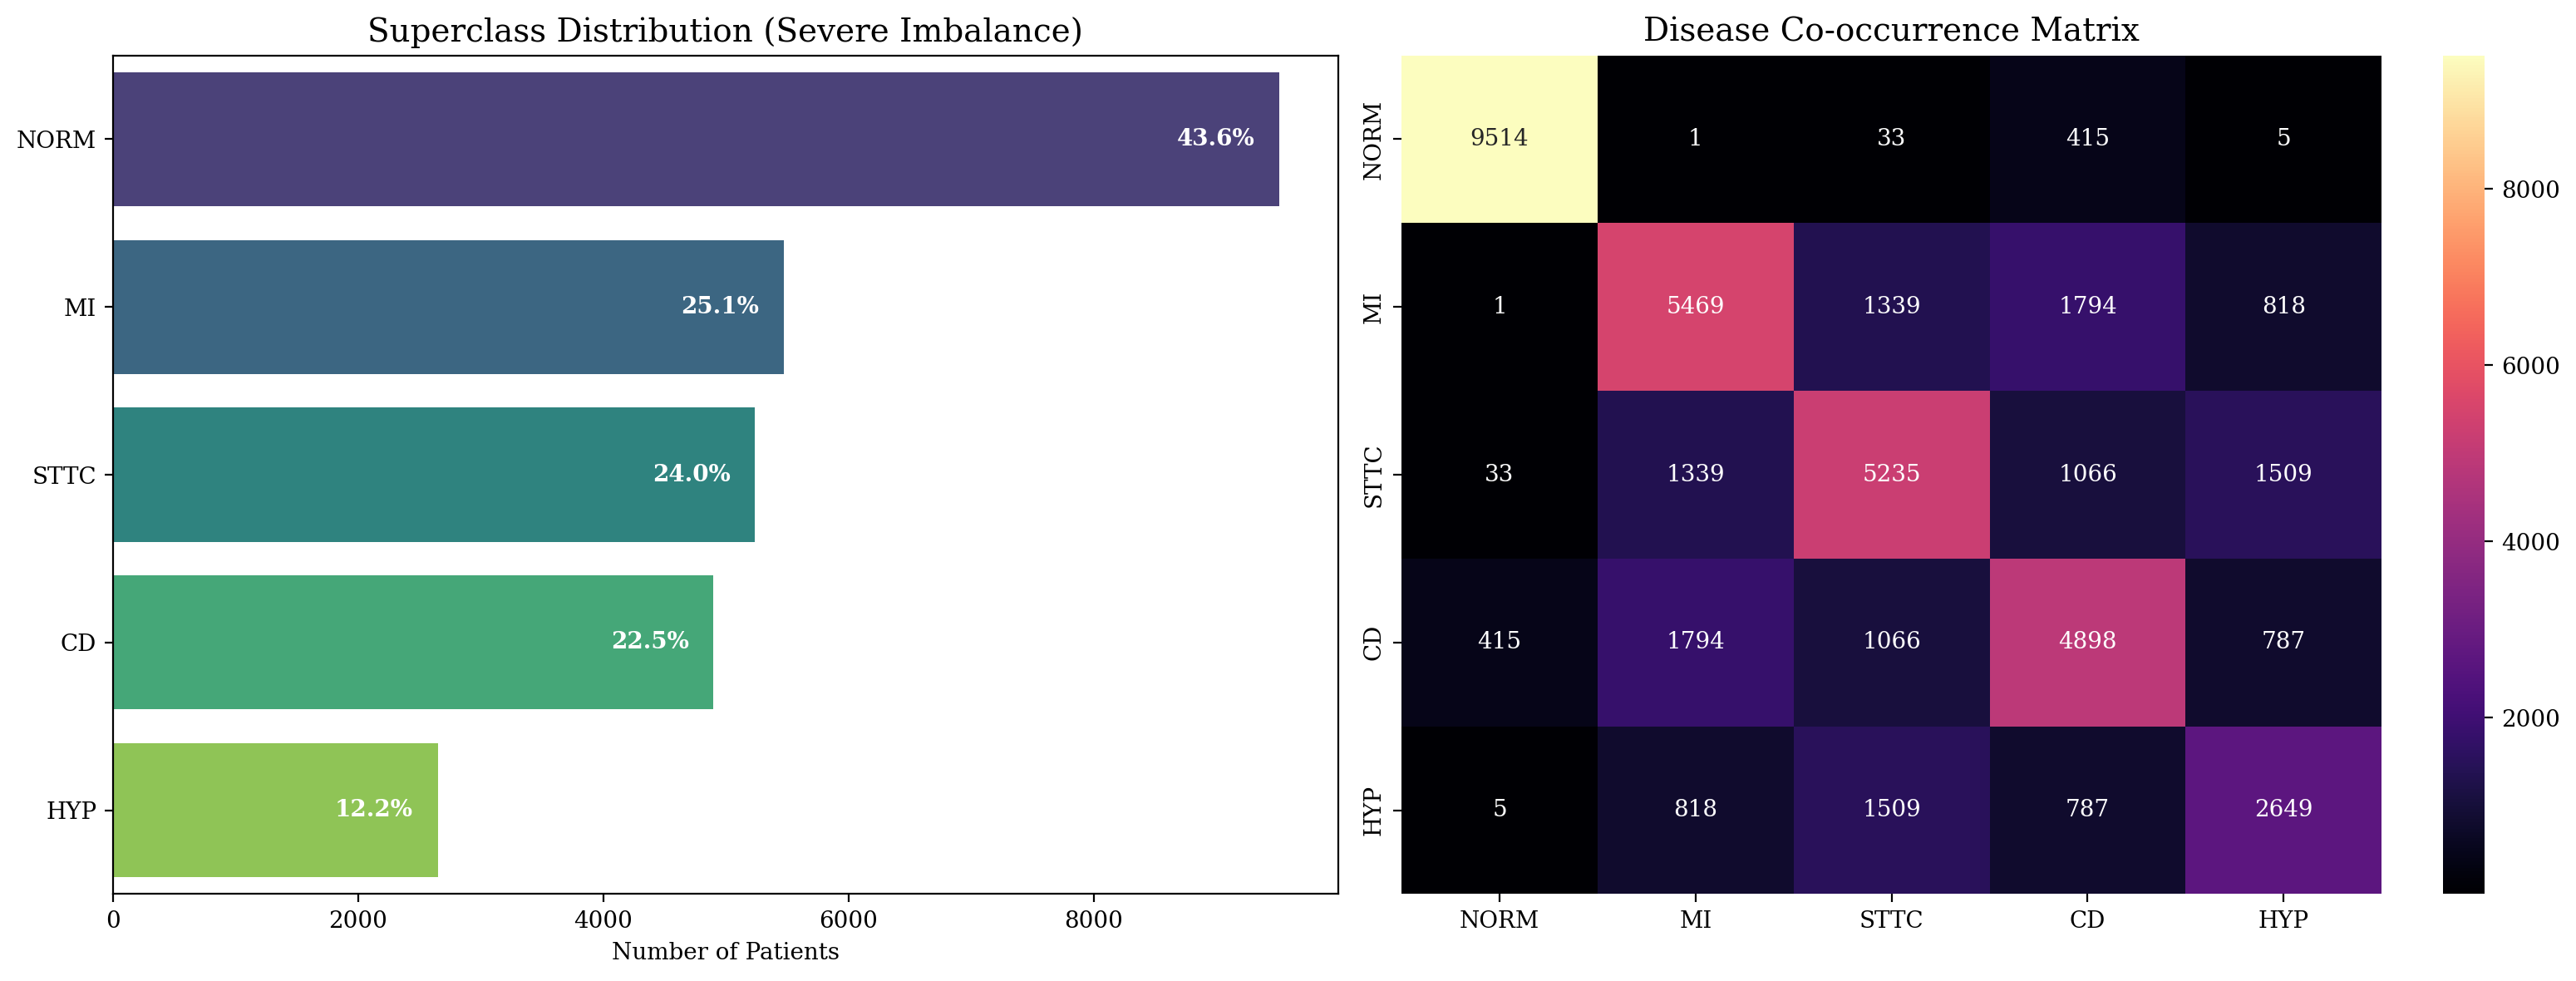

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


class_counts = df_ptbxl[superclasses].sum().sort_values(ascending=False)
sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Superclass Distribution (Severe Imbalance)", fontsize=14)
axes[0].set_xlabel("Number of Patients")
axes[0].set_ylabel(None)


total_patients = len(df_ptbxl)
for i, count in enumerate(class_counts.values):
    pct = (count / total_patients) * 100
    axes[0].text(count - 200, i, f'{pct:.1f}%', va='center', ha='right', fontweight='bold', color='white')

co_occurrence = df_ptbxl[superclasses].T.dot(df_ptbxl[superclasses])
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="magma", ax=axes[1])
axes[1].set_title("Disease Co-occurrence Matrix", fontsize=14)

plt.tight_layout()
plt.show()


Notice how often MI (Infarction) overlaps with STTC (ST/T Changes) and CD (Conduction).
When generating heatmaps later, the model might highlight a wide QRS (CD feature) to predict an MI because they co-occur so often in the training data.

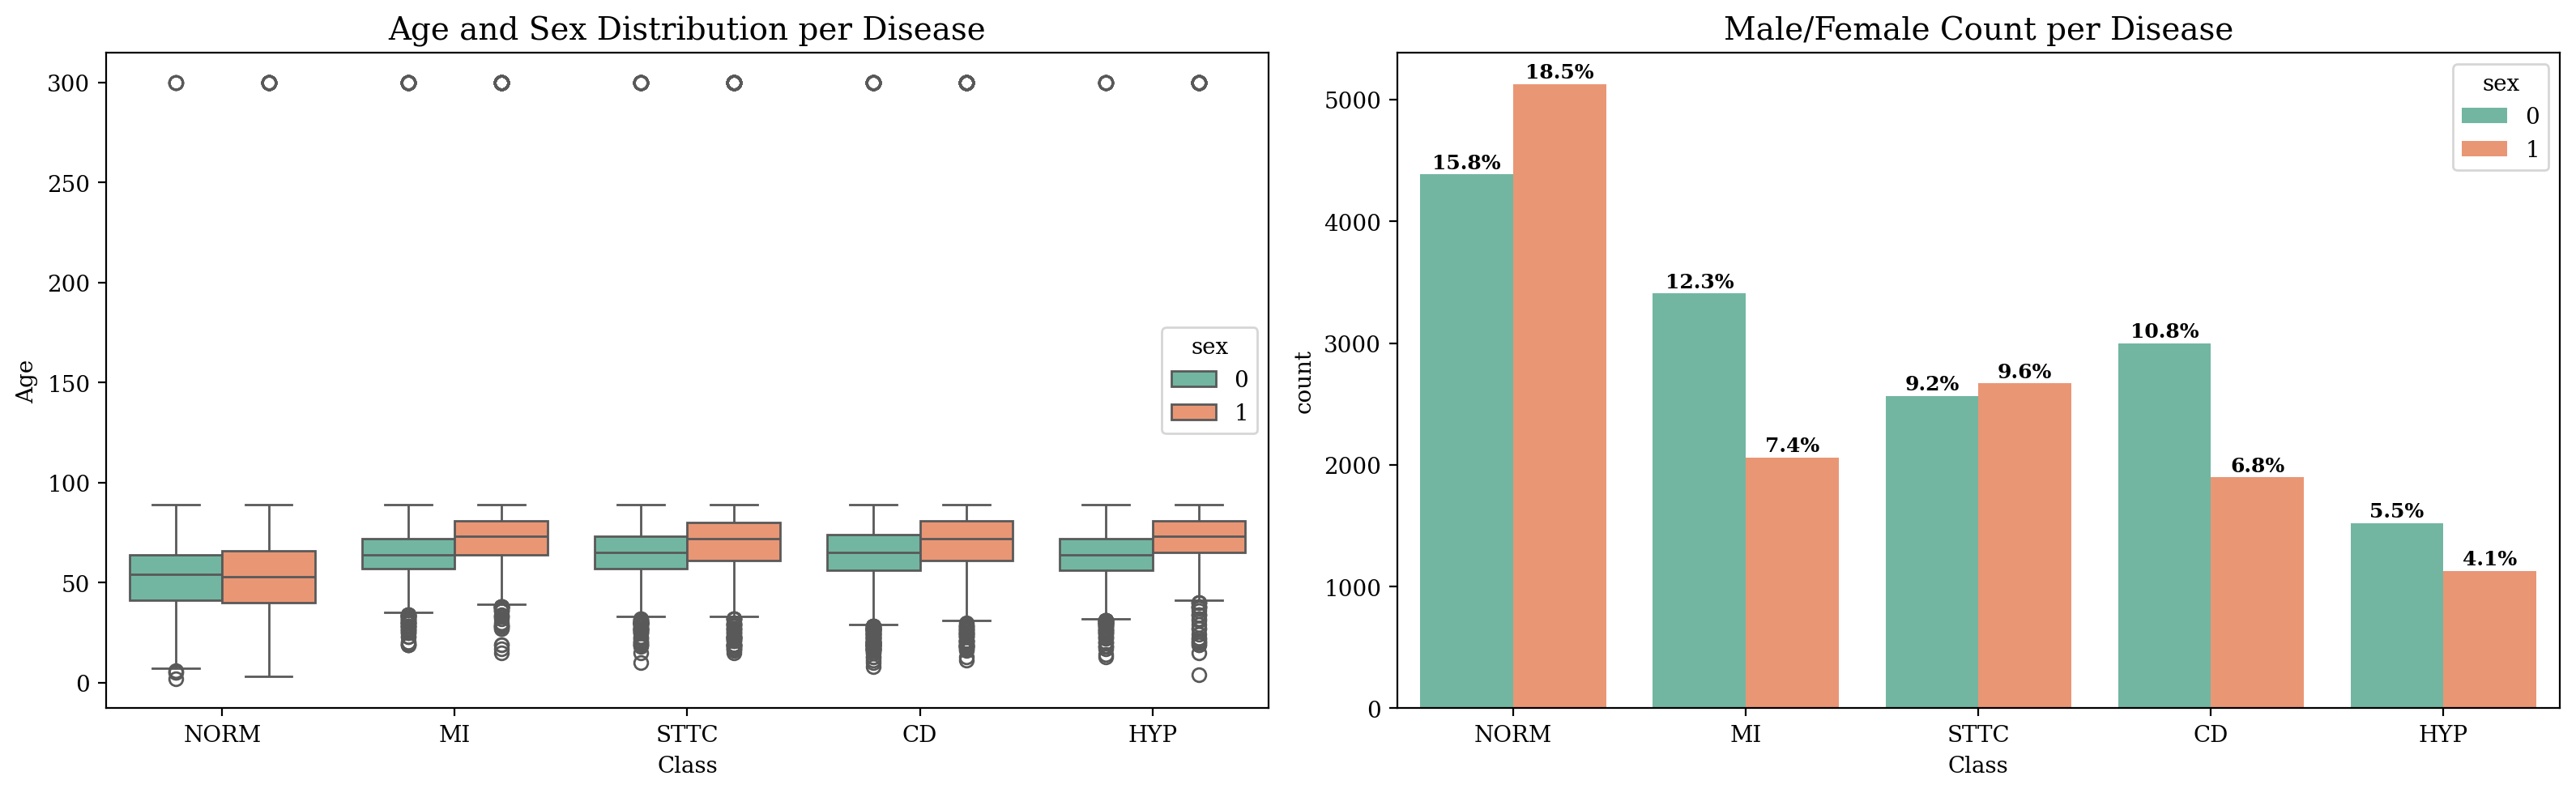

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_melt = pd.melt(df_ptbxl, id_vars=['age', 'sex'], value_vars=superclasses,
                  var_name='Class', value_name='Present')
df_present = df_melt[df_melt['Present'] == 1]

sns.boxplot(data=df_present, x='Class', y='age', hue='sex', palette="Set2", ax=axes[0])
axes[0].set_title("Age and Sex Distribution per Disease", fontsize=14)
axes[0].set_ylabel("Age")

ax_count = sns.countplot(data=df_present, x='Class', hue='sex', palette="Set2", ax=axes[1])
axes[1].set_title("Male/Female Count per Disease", fontsize=14)


total_present = len(df_present)
for p in ax_count.patches:
    if p.get_height() > 0:
        percentage = f'{100 * p.get_height() / total_present:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() + 50
        ax_count.annotate(percentage, (x, y), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

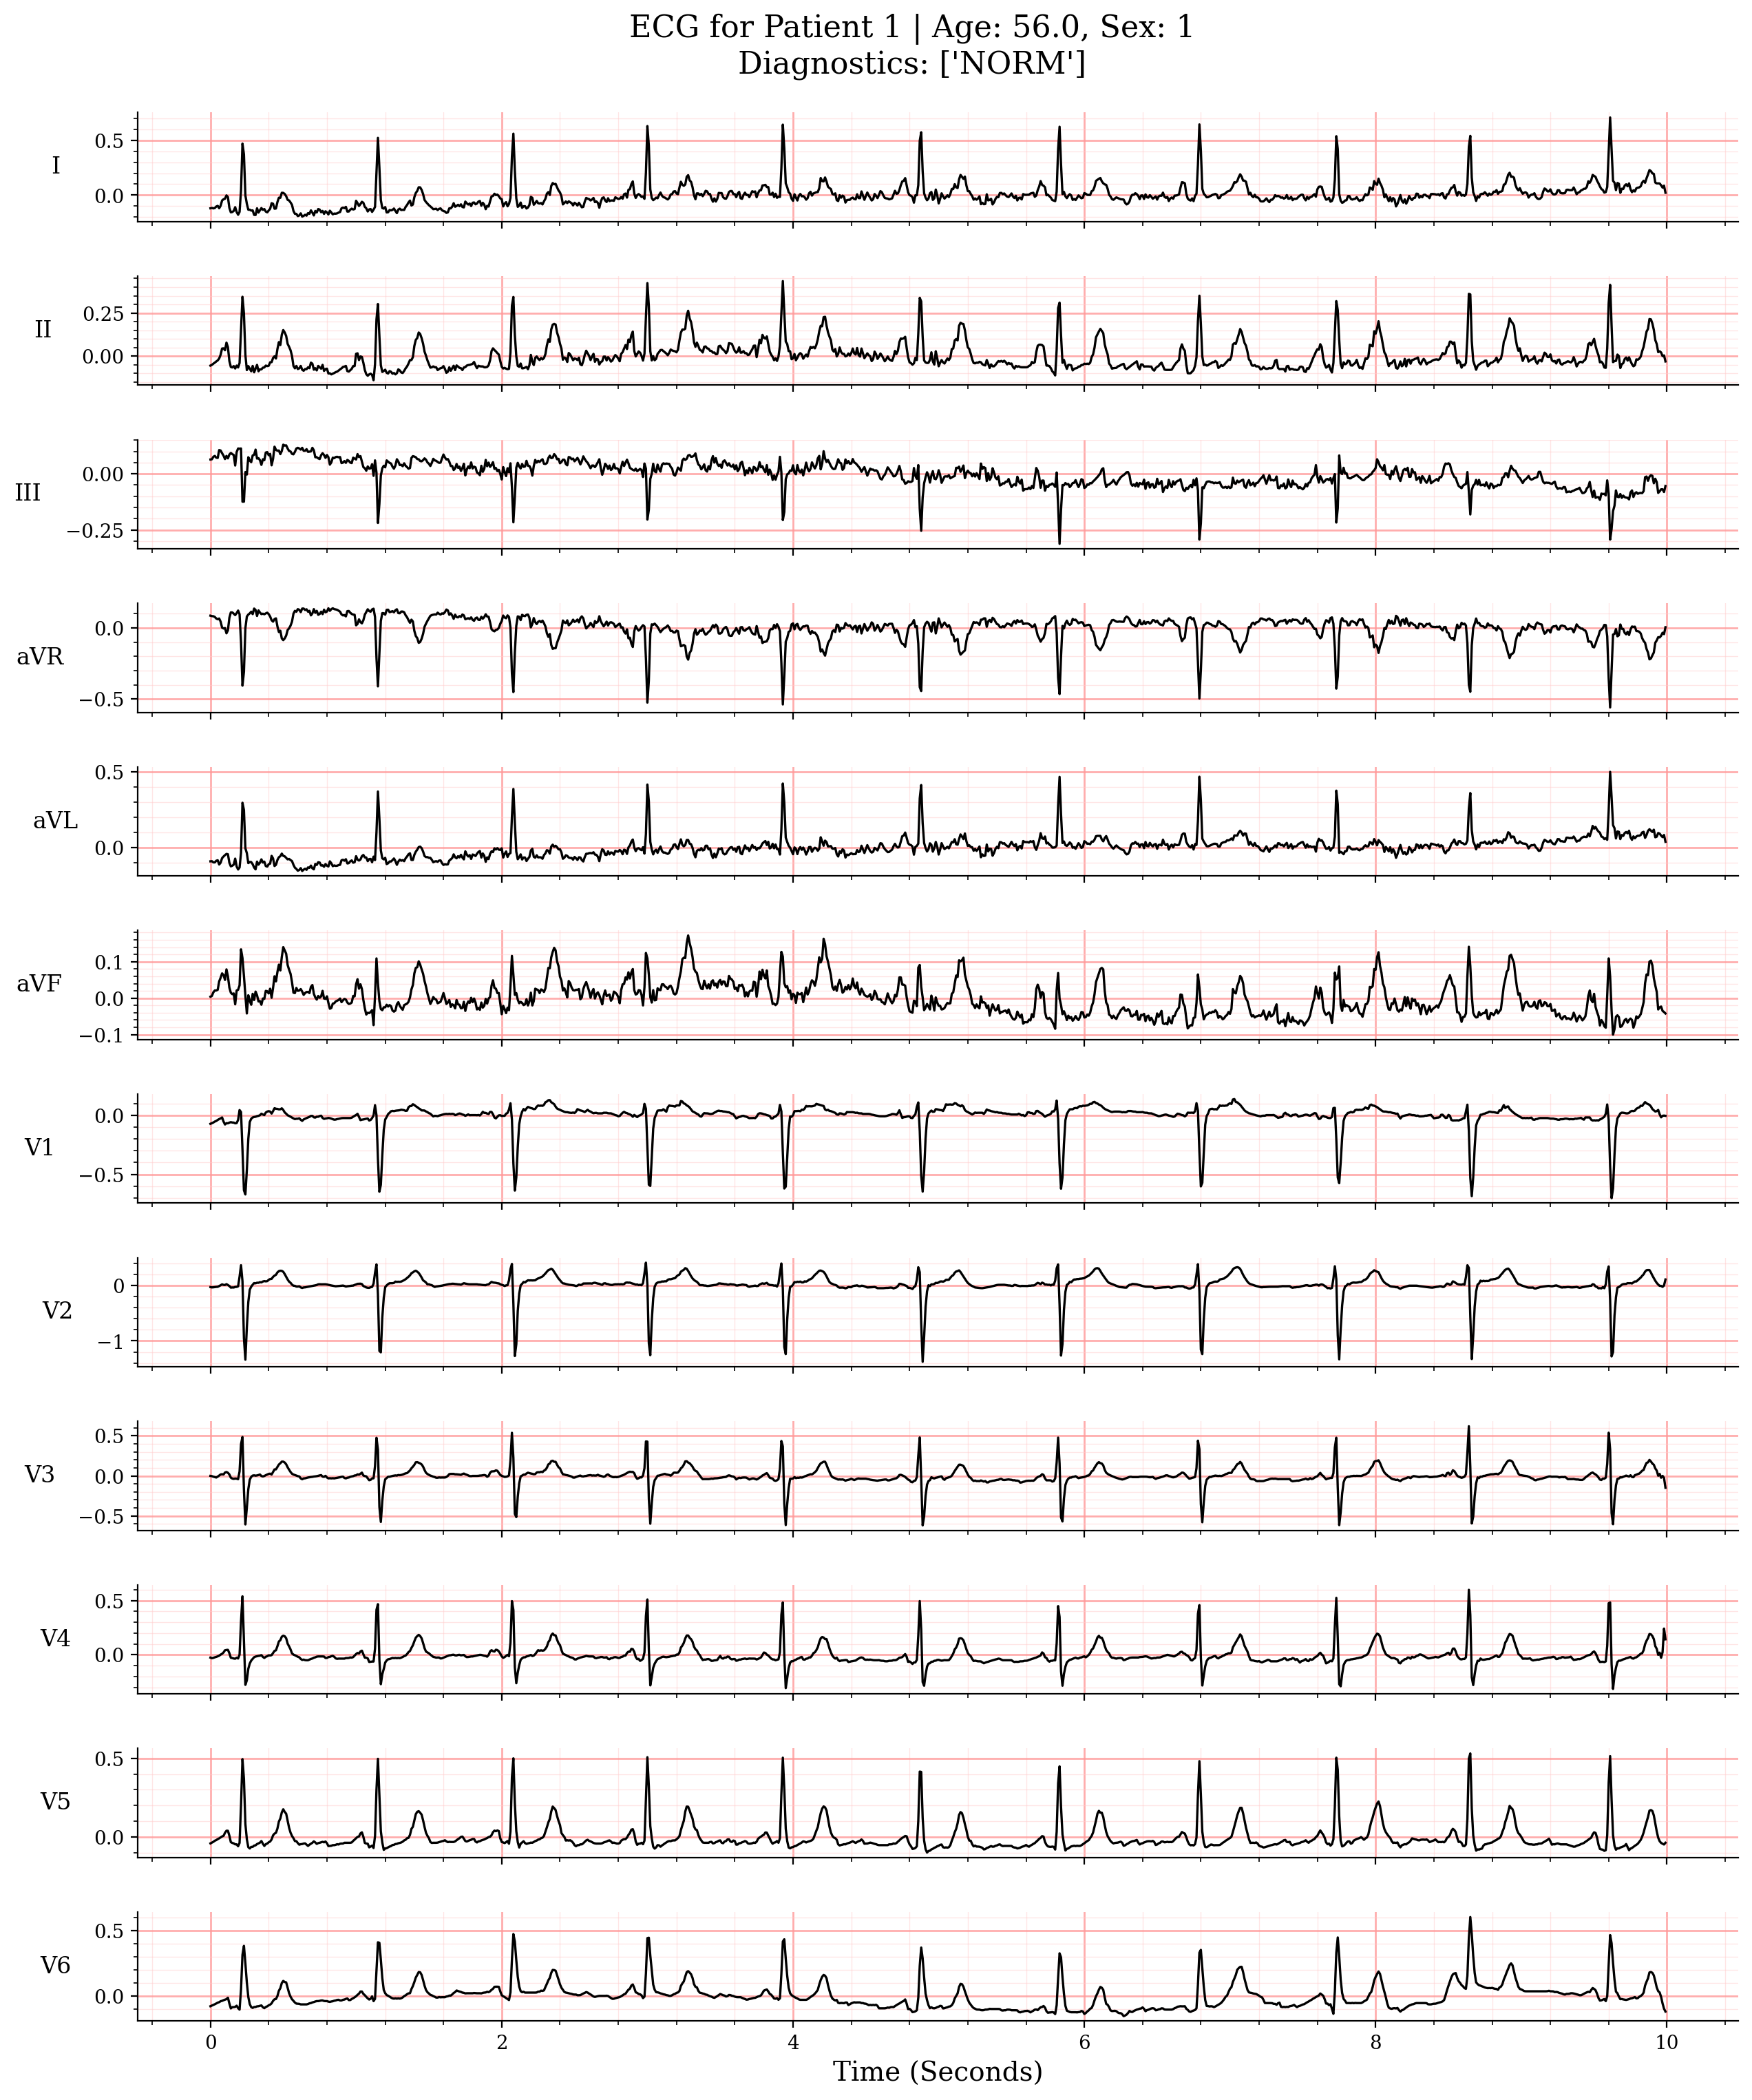

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

def plot_12_lead_ecg_clinical(signal_array, metadata_row, sampling_rate=100):

    leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


    time = np.arange(signal_array.shape[0]) / sampling_rate
    bg_color = '#ffffff'
    line_color = '#000000'
    major_grid_color = '#ff9999'
    minor_grid_color = '#ffcccc'

    fig, axes = plt.subplots(12, 1, figsize=(15, 18), sharex=True)
    fig.patch.set_facecolor(bg_color)


    labels = metadata_row['diagnostic_superclass']
    patient_age = metadata_row['age']
    patient_sex = metadata_row['sex']

    fig.suptitle(f"ECG for Patient {metadata_row.name} | Age: {patient_age}, Sex: {patient_sex}\nDiagnostics: {labels}",
                 fontsize=16, y=0.92, color='black')

    for i in range(12):
        axes[i].set_facecolor(bg_color)

        axes[i].plot(time, signal_array[:, i], color=line_color, linewidth=1.2)

        axes[i].set_ylabel(leads[i], fontsize=12, rotation=0, labelpad=20, va='center', color='black')


        axes[i].xaxis.set_minor_locator(AutoMinorLocator(5))
        axes[i].yaxis.set_minor_locator(AutoMinorLocator(5))

        axes[i].grid(True, which='major', color=major_grid_color, alpha=0.8, linewidth=1.0)
        axes[i].grid(True, which='minor', color=minor_grid_color, alpha=0.5, linewidth=0.5)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['bottom'].set_color('black')
        axes[i].spines['left'].set_color('black')
        axes[i].tick_params(colors='black')

    axes[-1].set_xlabel("Time (Seconds)", fontsize=14, color='black')
    plt.subplots_adjust(hspace=0.5)
    plt.show()


idx_norm = df_ptbxl[df_ptbxl['NORM'] == 1].index[0]
idx_mi = df_ptbxl[df_ptbxl['MI'] == 1].index[0]

array_idx_norm = df_ptbxl.index.get_loc(idx_norm)
array_idx_mi = df_ptbxl.index.get_loc(idx_mi)
plot_12_lead_ecg_clinical(X[array_idx_norm], df_ptbxl.iloc[array_idx_norm])


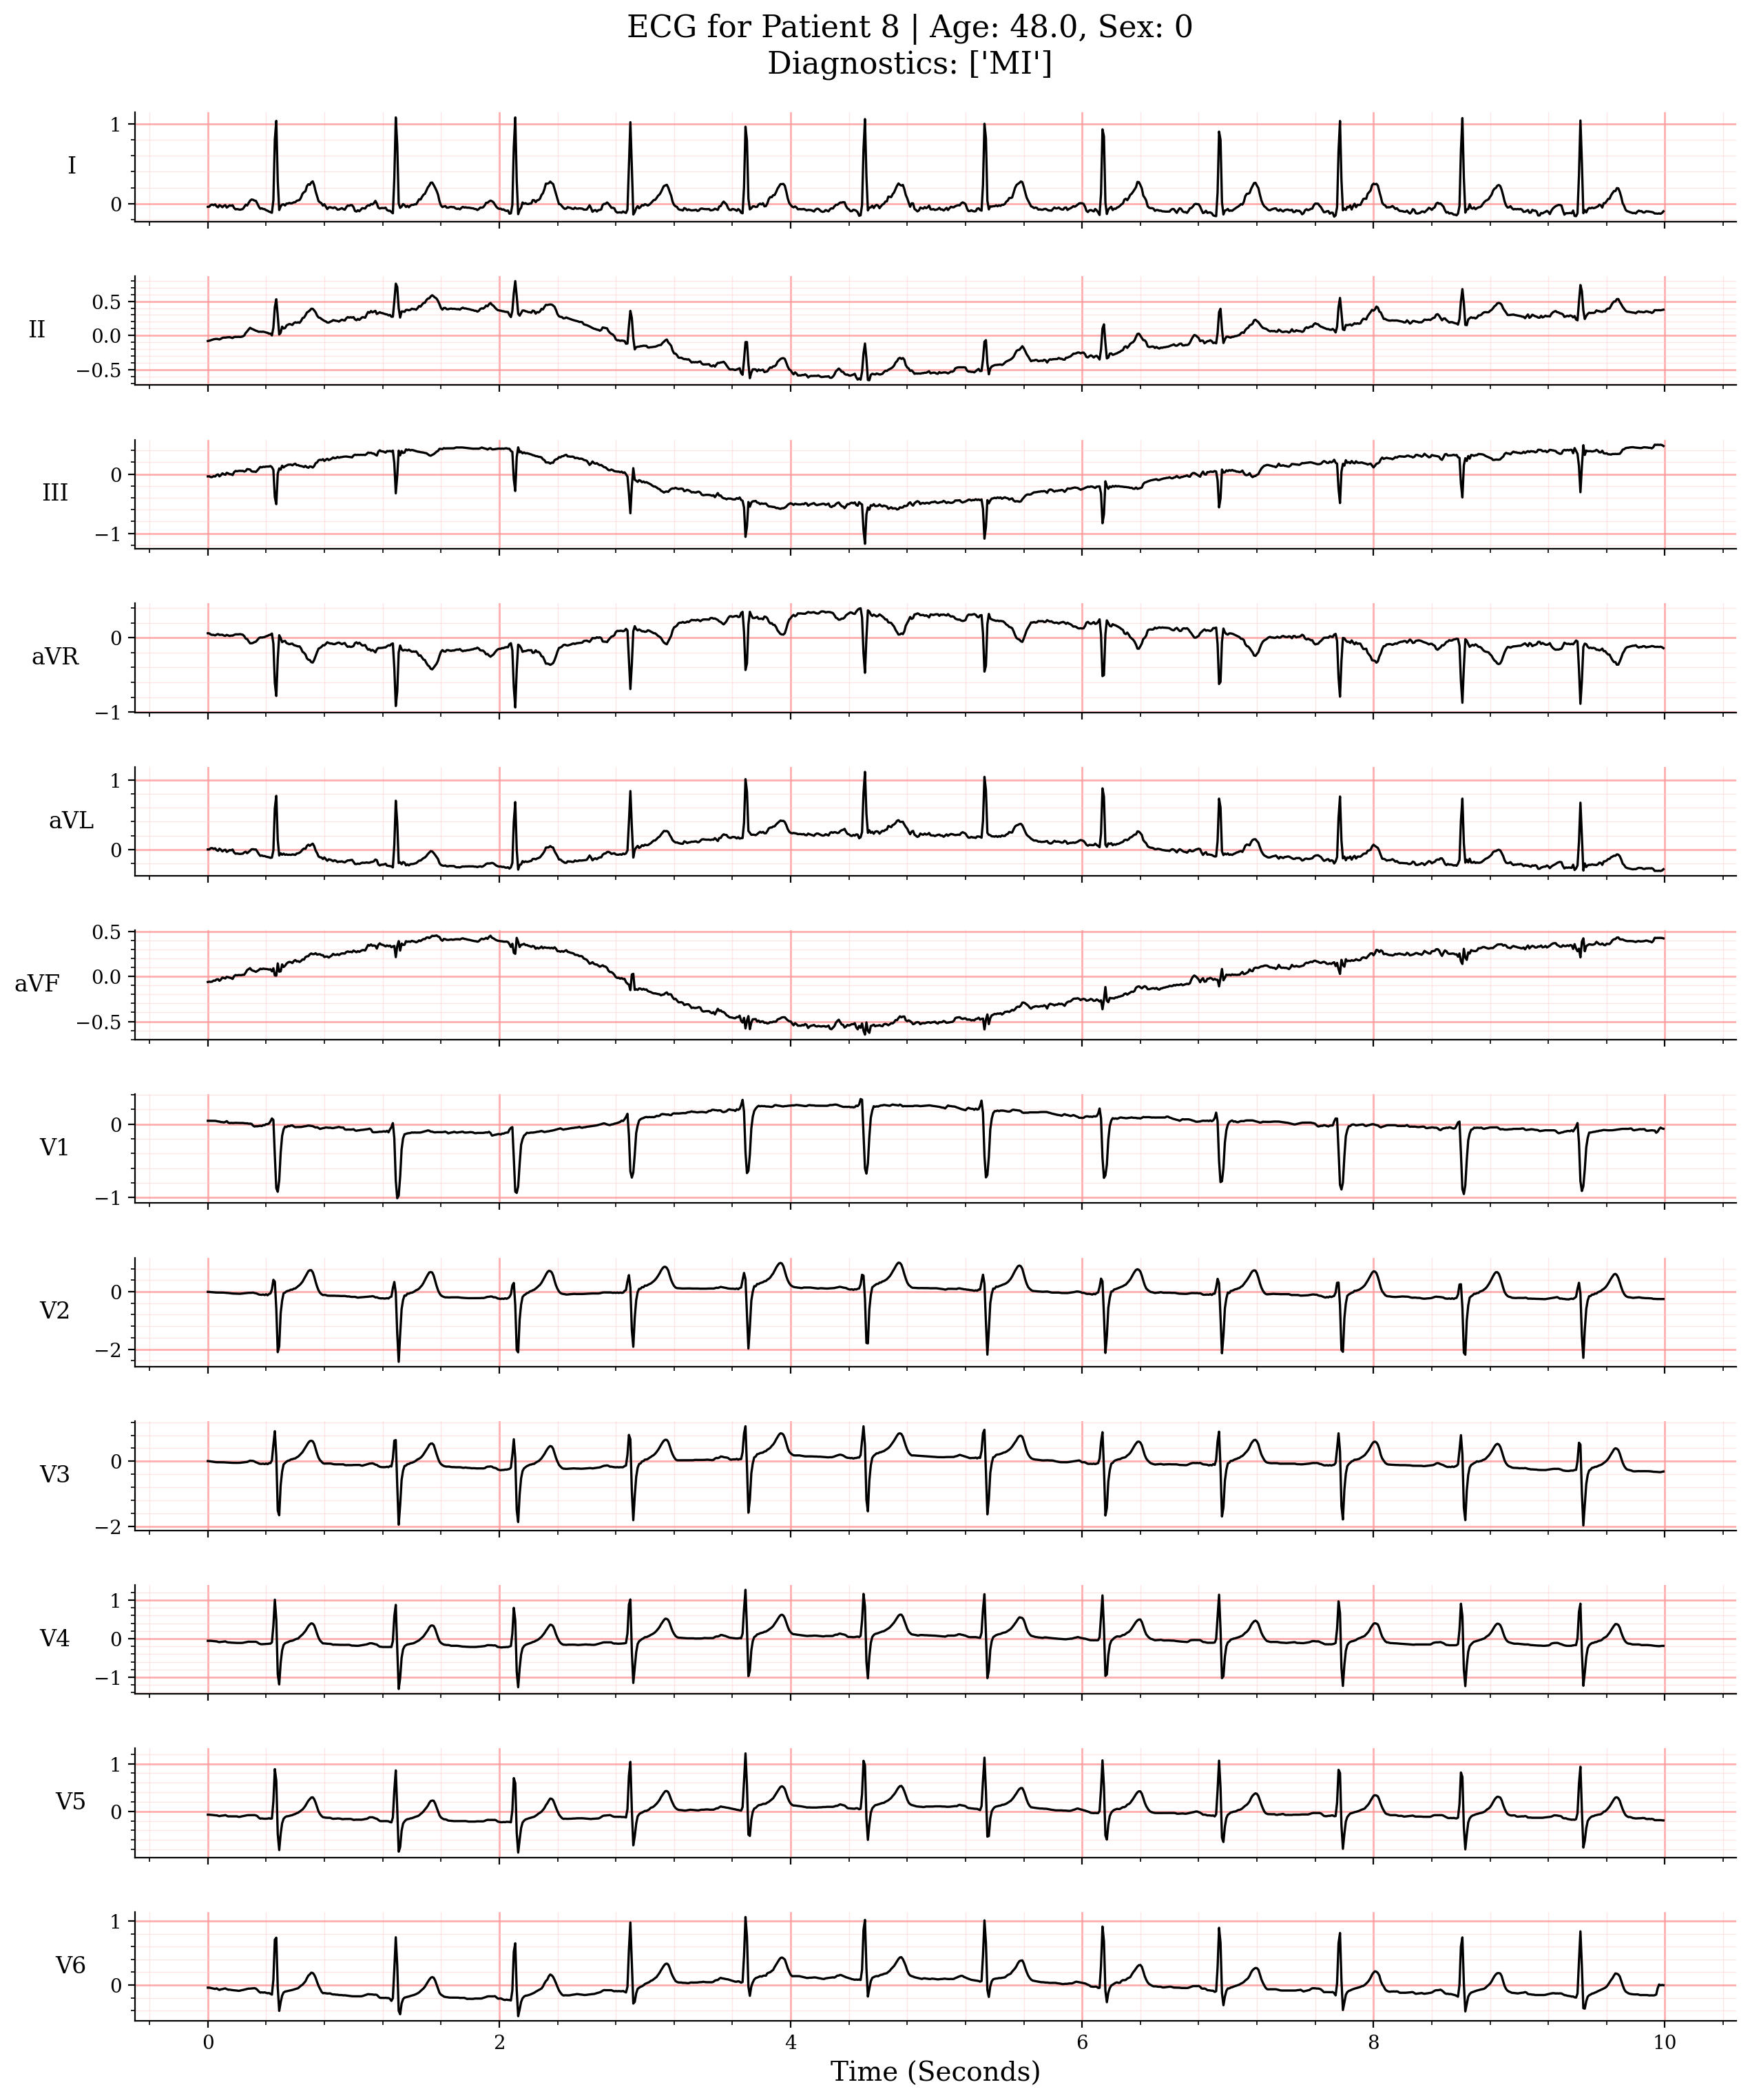

In [ ]:
plot_12_lead_ecg_clinical(X[array_idx_mi], df_ptbxl.iloc[array_idx_mi])

In [ ]:
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

print("=== Signal Array Statistics ===")
print(f"Shape        : {X.shape}  → (records, timesteps, leads)")
print(f"Dtype        : {X.dtype}")
print(f"NaN count    : {np.isnan(X).sum()}")
print(f"Inf count    : {np.isinf(X).sum()}")
print(f"Global min   : {X.min():.4f} mV")
print(f"Global max   : {X.max():.4f} mV")
print(f"Global mean  : {X.mean():.6f} mV")
print(f"Global std   : {X.std():.4f} mV")

print("\n=== Per-Lead Statistics ===")
print(f"{'Lead':<6} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 45)
for i, name in enumerate(LEAD_NAMES):
    lead_data = X[:, :, i]
    print(f"{name:<6} {lead_data.mean():>8.4f} {lead_data.std():>8.4f} "
          f"{lead_data.min():>8.4f} {lead_data.max():>8.4f}")

=== Signal Array Statistics ===
Shape        : (21799, 1000, 12)  → (records, timesteps, leads)
Dtype        : float64
NaN count    : 0
Inf count    : 0
Global min   : -20.0320 mV
Global max   : 17.2120 mV
Global mean  : -0.000781 mV
Global std   : 0.2354 mV

=== Per-Lead Statistics ===
Lead       Mean      Std      Min      Max
---------------------------------------------
I       -0.0016   0.1596  -7.4550   4.3980
II      -0.0013   0.1647  -5.8560   5.5760
III      0.0003   0.1670  -4.6560   7.4910
aVR      0.0014   0.1391  -3.6790   5.9200
aVL     -0.0009   0.1411  -7.4730   4.4250
aVF     -0.0005   0.1453  -5.3000   5.5530
V1       0.0002   0.2337 -17.8250  10.5470
V2      -0.0009   0.3377 -11.1020  12.1570
V3      -0.0015   0.3337 -16.3200   8.5050
V4      -0.0017   0.3058 -11.1980   8.6960
V5      -0.0008   0.2731 -13.0550  17.2120
V6      -0.0021   0.2756 -20.0320  12.9660


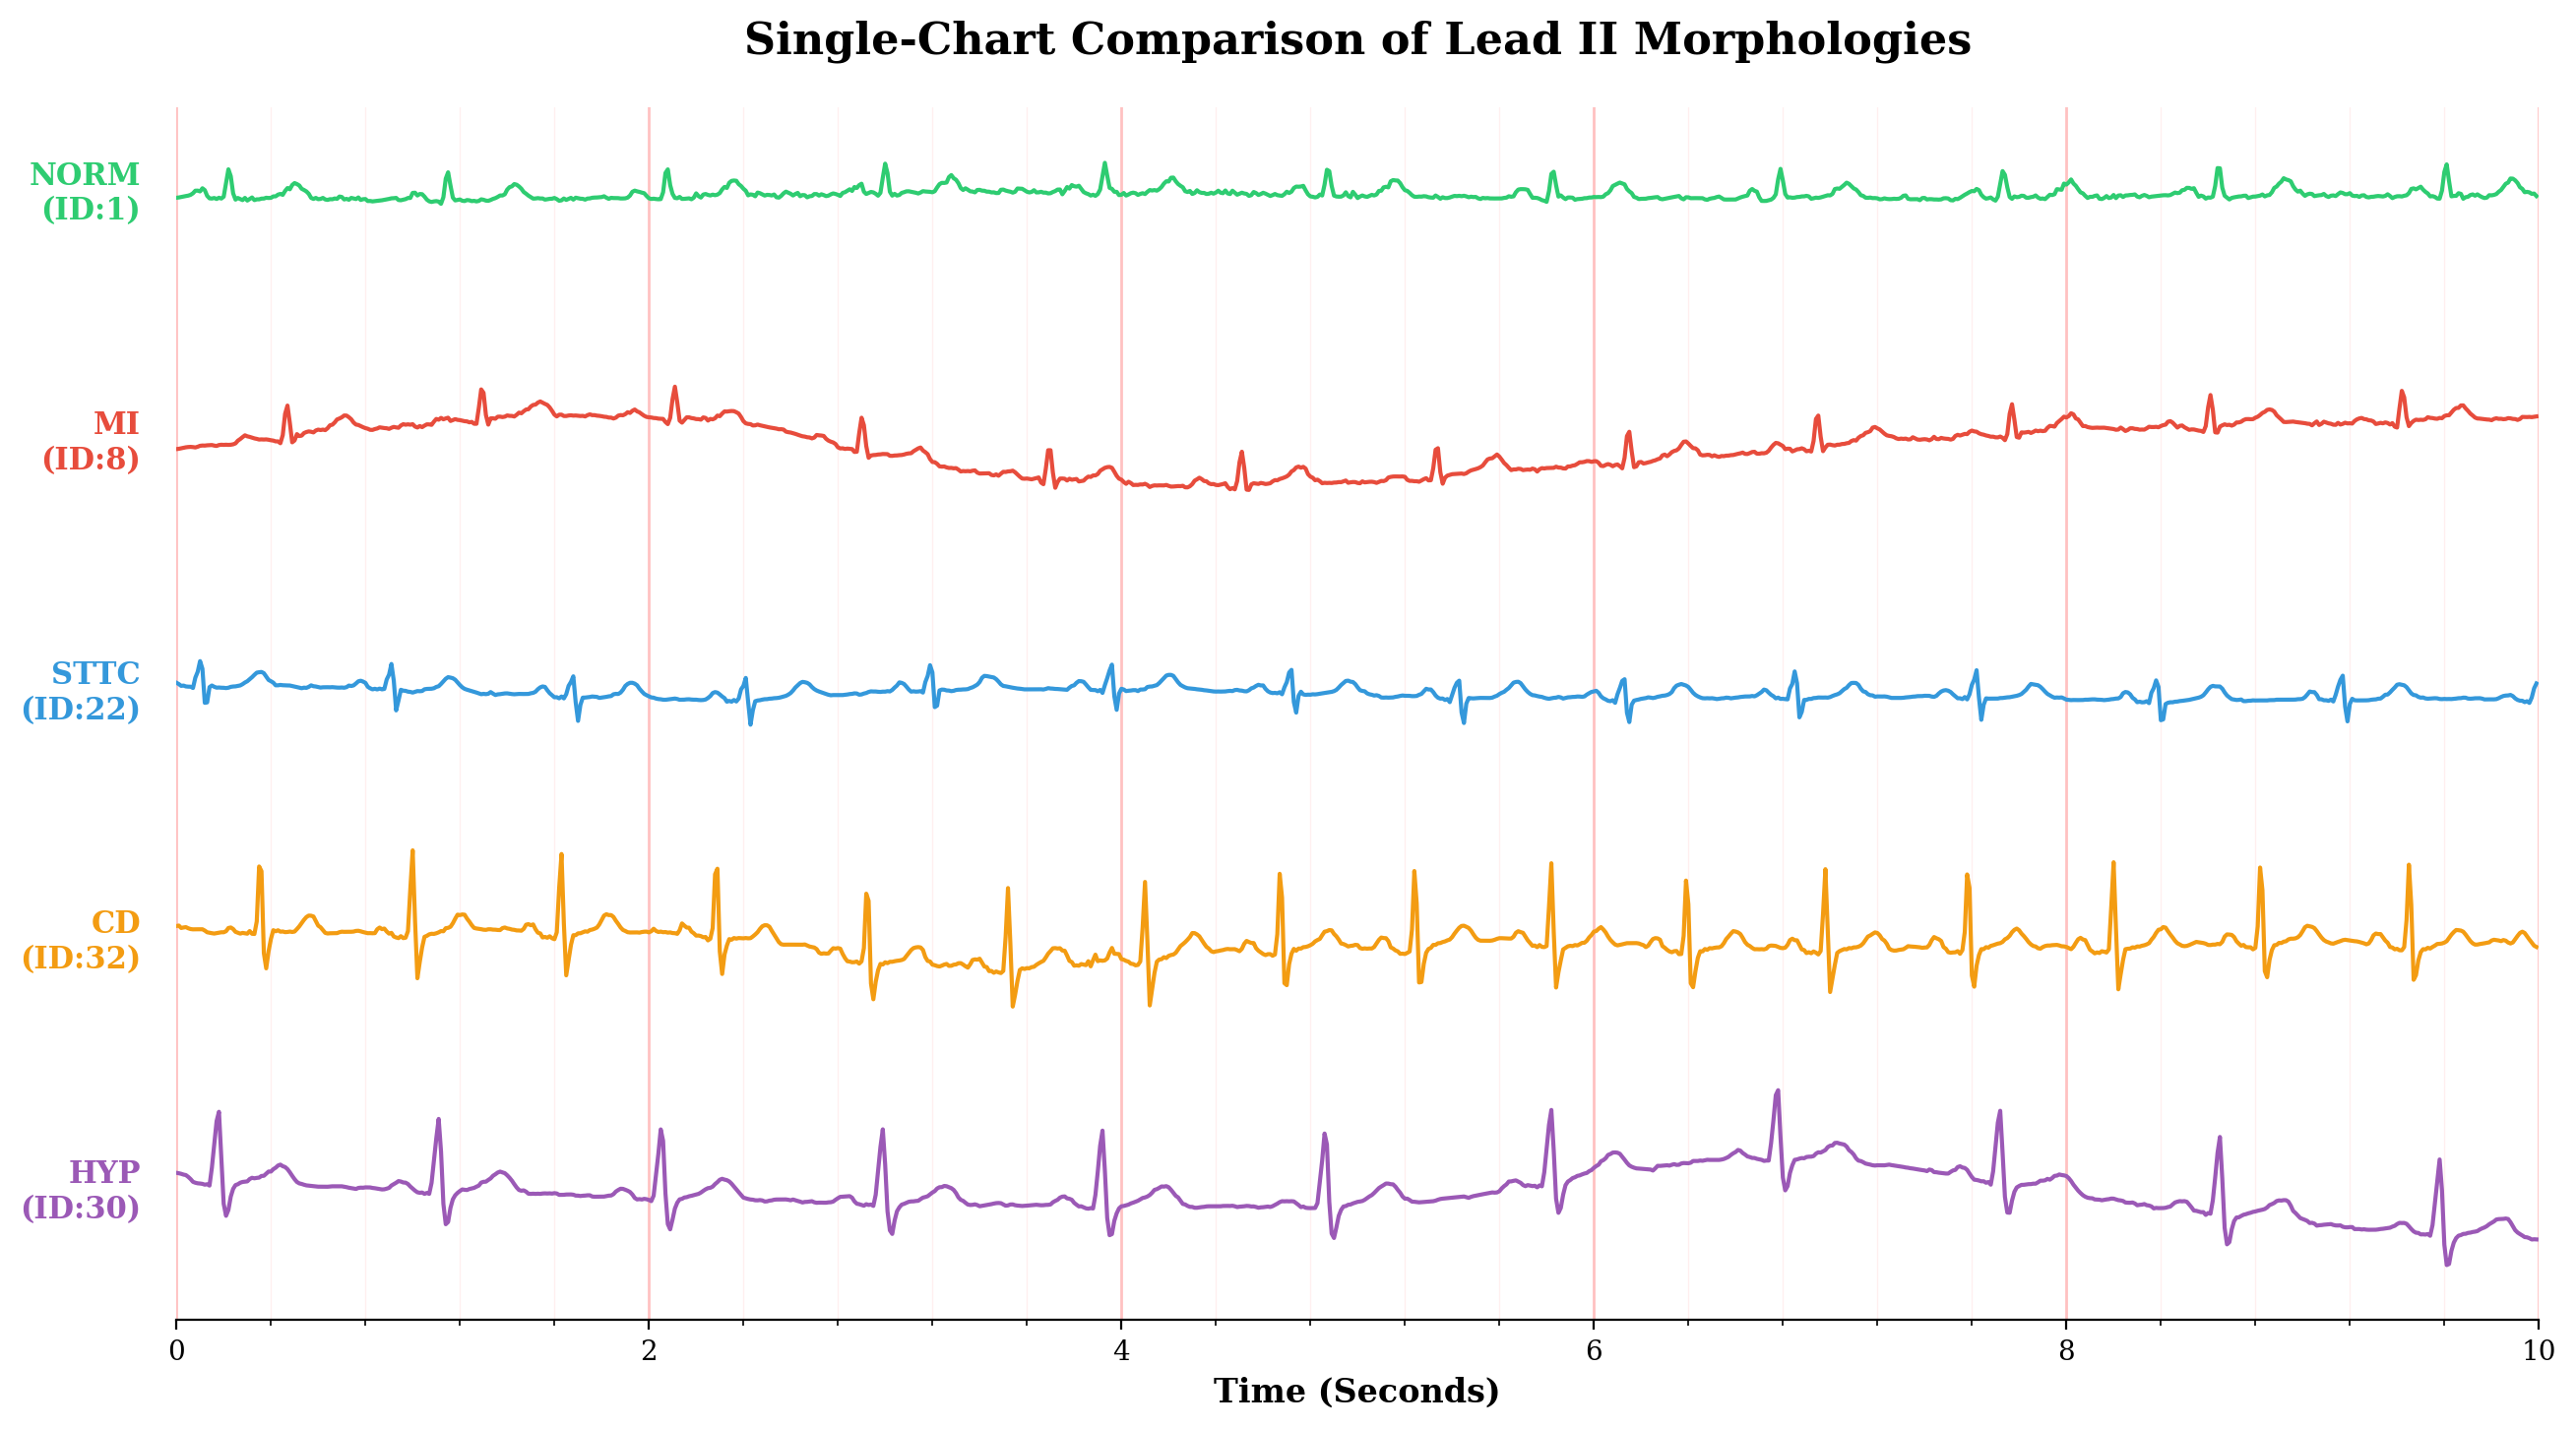

In [ ]:
from matplotlib.ticker import AutoMinorLocator

def plot_lead_ii_combined(X_data, metadata_df, fs=100):

    superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
    LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
    lead_idx = LEAD_NAMES.index('II')
    time = np.arange(X_data.shape[1]) / fs
    fig, ax = plt.subplots(figsize=(15, 8))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#ffffff')

    colors = {'NORM': '#2ecc71', 'MI': '#e74c3c', 'STTC': '#3498db',
              'CD': '#f39c12', 'HYP': '#9b59b6'}

    offset_step = 3.5

    for i, label in enumerate(superclasses):
        patient_idx = metadata_df[metadata_df[label] == 1].index[0]
        array_pos = metadata_df.index.get_loc(patient_idx)
        signal = X_data[array_pos, :, lead_idx]

        current_offset = (len(superclasses) - i - 1) * offset_step
        shifted_signal = signal + current_offset
        ax.plot(time, shifted_signal, color=colors[label], linewidth=1.5)
        ax.text(-0.15, current_offset, f"{label}\n(ID:{patient_idx})",
                fontsize=11, fontweight='bold', color=colors[label],
                va='center', ha='right')
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.grid(True, which='major', color='#ff9999', alpha=0.6, linewidth=1.0)
    ax.grid(True, which='minor', color='#ffcccc', alpha=0.3, linewidth=0.5)


    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.spines['bottom'].set_color('black')
    ax.tick_params(colors='black')

    ax.set_xlabel('Time (Seconds)', fontsize=12, fontweight='bold', color='black')
    ax.set_title('Single-Chart Comparison of Lead II Morphologies',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlim([0, 10])

    plt.subplots_adjust(left=0.1)
    plt.show()

plot_lead_ii_combined(X, df_ptbxl)

# Preprocessing

removing noisy waves

The bandpass filter clips slow waves below 0.5 Hz, which contain the baseline wander caused by breathing, and clips fast waves above 40 Hz, which contain the static noise caused by muscle twitches and hospital powerlines.

In [ ]:
from scipy.signal import butter, filtfilt
from tqdm import tqdm

def apply_bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')

    # Apply zero-phase filter (filtfilt) so we don't shift the phase/timing of the QRS complexes
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

print(f"Old Signal Range: {X.min():.4f} to {X.max():.4f} mV")


Old Signal Range: -20.0320 to 17.2120 mV


Scales the voltage so the neural network focuses entirely on the shape and morphology of the wave rather than exploding gradients on absolute voltage.

In [ ]:
from sklearn.preprocessing import StandardScaler

def normalize_signal(signal):
    normalized_signal = signal.reshape(-1, 1)
    scaler = StandardScaler()
    scaler.fit_transform(normalized_signal)
    return np.array(normalized_signal.flatten())

def clean(signals:np.ndarray, bandpass_range=[-float('inf'), float('inf')], normalize=False, bandpass_order=3):
    processed = np.zeros_like(X)

    for i in tqdm(range(X.shape[0]), desc="Cleaning Signal"):
        for lead in range(12):
            patient_signal = X[i][:, lead]

            lowcut, highcut=bandpass_range
            cleaned = apply_bandpass_filter(patient_signal, lowcut=lowcut, highcut=highcut, order=bandpass_order)

            if normalize:
                cleaned = normalize_signal(cleaned)

            processed[i][:, lead] = cleaned

    return processed

In [ ]:
X_processed = clean(X, bandpass_range=[0.5, 40], normalize=True)
print(f"New Signal Range (Z-scores): {X_processed.min():.4f} to {X_processed.max():.4f}")

Cleaning Signal: 100%|██████████| 21799/21799 [05:41<00:00, 63.76it/s]


New Signal Range (Z-scores): -17.5913 to 11.4792


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Y = df_ptbxl[superclasses].values

train_mask = df_ptbxl['strat_fold'] <= 8
val_mask = df_ptbxl['strat_fold'] == 9
test_mask = df_ptbxl['strat_fold'] == 10

X_train, Y_train = X_processed[train_mask], Y[train_mask]
X_val, Y_val     = X_processed[val_mask], Y[val_mask]
X_test, Y_test   = X_processed[test_mask], Y[test_mask]

print("=== Dataset Splits ===")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples  : {X_val.shape[0]}")
print(f"Test samples : {X_test.shape[0]}")


class ECGDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        # Extract signal and label
        signal = self.x_data[idx]
        label = self.y_data[idx]

        # PyTorch 1D CNNs expect [Channels, Sequence_Length]
        signal = np.transpose(signal, (1, 0))
        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return signal_tensor, label_tensor

train_dataset = ECGDataset(X_train, Y_train)
val_dataset   = ECGDataset(X_val, Y_val)
test_dataset  = ECGDataset(X_test, Y_test)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample_batch_x, sample_batch_y = next(iter(train_loader))
print("\n=== DataLoader Sanity Check ===")
print(f"Input Batch Shape  : {sample_batch_x.shape} -> [Batch, Leads, Time]")
print(f"Target Batch Shape : {sample_batch_y.shape} -> [Batch, Classes]")

=== Dataset Splits ===
Train samples: 17418
Val samples  : 2183
Test samples : 2198

=== DataLoader Sanity Check ===
Input Batch Shape  : torch.Size([64, 12, 1000]) -> [Batch, Leads, Time]
Target Batch Shape : torch.Size([64, 5]) -> [Batch, Classes]


# Modeling

## Model 1: 1D Incpetion Network (Elgohary)

In [ ]:
import torch
import torch.nn as nn

class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(InceptionBlock1D, self).__init__()

        self.bottleneck = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding=0)
        self.conv_branch_1 = nn.Conv1d(out_channels, out_channels, kernel_size=9, padding=4)
        self.conv_branch_2 = nn.Conv1d(out_channels, out_channels, kernel_size=19, padding=9)
        self.conv_branch_3 = nn.Conv1d(out_channels, out_channels, kernel_size=39, padding=19)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.pool_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding=0)

    def forward(self, x):
        x_bottleneck = self.bottleneck(x)
        b1 = self.conv_branch_1(x_bottleneck)
        b2 = self.conv_branch_2(x_bottleneck)
        b3 = self.conv_branch_3(x_bottleneck)
        b4 = self.pool_conv(self.maxpool(x))
        return torch.cat([b1, b2, b3, b4], dim=1)

dummy_batch = torch.randn(64, 12, 1000)
inception_layer = InceptionBlock1D(in_channels=12, out_channels=32)

output = inception_layer(dummy_batch)
print(f"Output Shape: {output.shape}")


Output Shape: torch.Size([64, 128, 1000])


In [ ]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np
import os


class ECG_Inception_Net(nn.Module):
    def __init__(self, in_channels=12, num_classes=5):
        super(ECG_Inception_Net, self).__init__()
        self.block1 = InceptionBlock1D(in_channels=in_channels, out_channels=32)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.block2 = InceptionBlock1D(in_channels=128, out_channels=64)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.block2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)

        logits = self.fc(x)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECG_Inception_Net().to(device)
print(f"Model deployed on: {device}")

Model deployed on: cuda


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_auc_score

EPOCHS = 40
PATIENCE = 7
epochs_no_improve = 0

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

save_dir = '/content/drive/MyDrive/XAI_Project/'
os.makedirs(save_dir, exist_ok=True)
best_val_auc = 0.0

print(f"Starting Training Loop for up to {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    val_auc = roc_auc_score(all_targets, all_preds, average='macro')

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro AUROC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(save_dir, 'best_inception1d_model.pth'))
        print(f"  --> Saved New Best Model! (AUROC: {best_val_auc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  --> No improvement in AUROC for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= PATIENCE:
            print(f"\n[!] Early Stopping Triggered at Epoch {epoch+1}.")
            print(f"Restoring best model weights from Epoch {epoch+1 - PATIENCE} (AUROC: {best_val_auc:.4f})")
            break

print("\nTraining Complete.")

Starting Training Loop for up to 40 Epochs...
Epoch 01/40 | Train Loss: 0.4226 | Val Loss: 0.3498 | Val Macro AUROC: 0.8781
  --> Saved New Best Model! (AUROC: 0.8781)
Epoch 02/40 | Train Loss: 0.3259 | Val Loss: 0.3351 | Val Macro AUROC: 0.8983
  --> Saved New Best Model! (AUROC: 0.8983)
Epoch 03/40 | Train Loss: 0.3031 | Val Loss: 0.3140 | Val Macro AUROC: 0.9052
  --> Saved New Best Model! (AUROC: 0.9052)
Epoch 04/40 | Train Loss: 0.2902 | Val Loss: 0.3149 | Val Macro AUROC: 0.9105
  --> Saved New Best Model! (AUROC: 0.9105)
Epoch 05/40 | Train Loss: 0.2803 | Val Loss: 0.2999 | Val Macro AUROC: 0.9143
  --> Saved New Best Model! (AUROC: 0.9143)
Epoch 06/40 | Train Loss: 0.2746 | Val Loss: 0.3055 | Val Macro AUROC: 0.9148
  --> Saved New Best Model! (AUROC: 0.9148)
Epoch 07/40 | Train Loss: 0.2684 | Val Loss: 0.3152 | Val Macro AUROC: 0.9133
  --> No improvement in AUROC for 1 epoch(s).
Epoch 08/40 | Train Loss: 0.2626 | Val Loss: 0.2926 | Val Macro AUROC: 0.9170
  --> Saved New Best

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score
import os

model.eval()

all_targets_test = []
all_preds_test = []

print("Running evaluation on test set...")


with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        outputs = model(batch_x)
        probs = torch.sigmoid(outputs)

        all_preds_test.append(probs.cpu().numpy())
        all_targets_test.append(batch_y.cpu().numpy())

all_preds_test = np.vstack(all_preds_test)
all_targets_test = np.vstack(all_targets_test)

test_auc = roc_auc_score(all_targets_test, all_preds_test, average='macro')

print("=== Test Evaluation Results ===")
print(f"Test Macro AUROC: {test_auc:.4f}")

Running evaluation on test set...
=== Test Evaluation Results ===
Test Macro AUROC: 0.9223


### Interpretation

# 1- SHAP

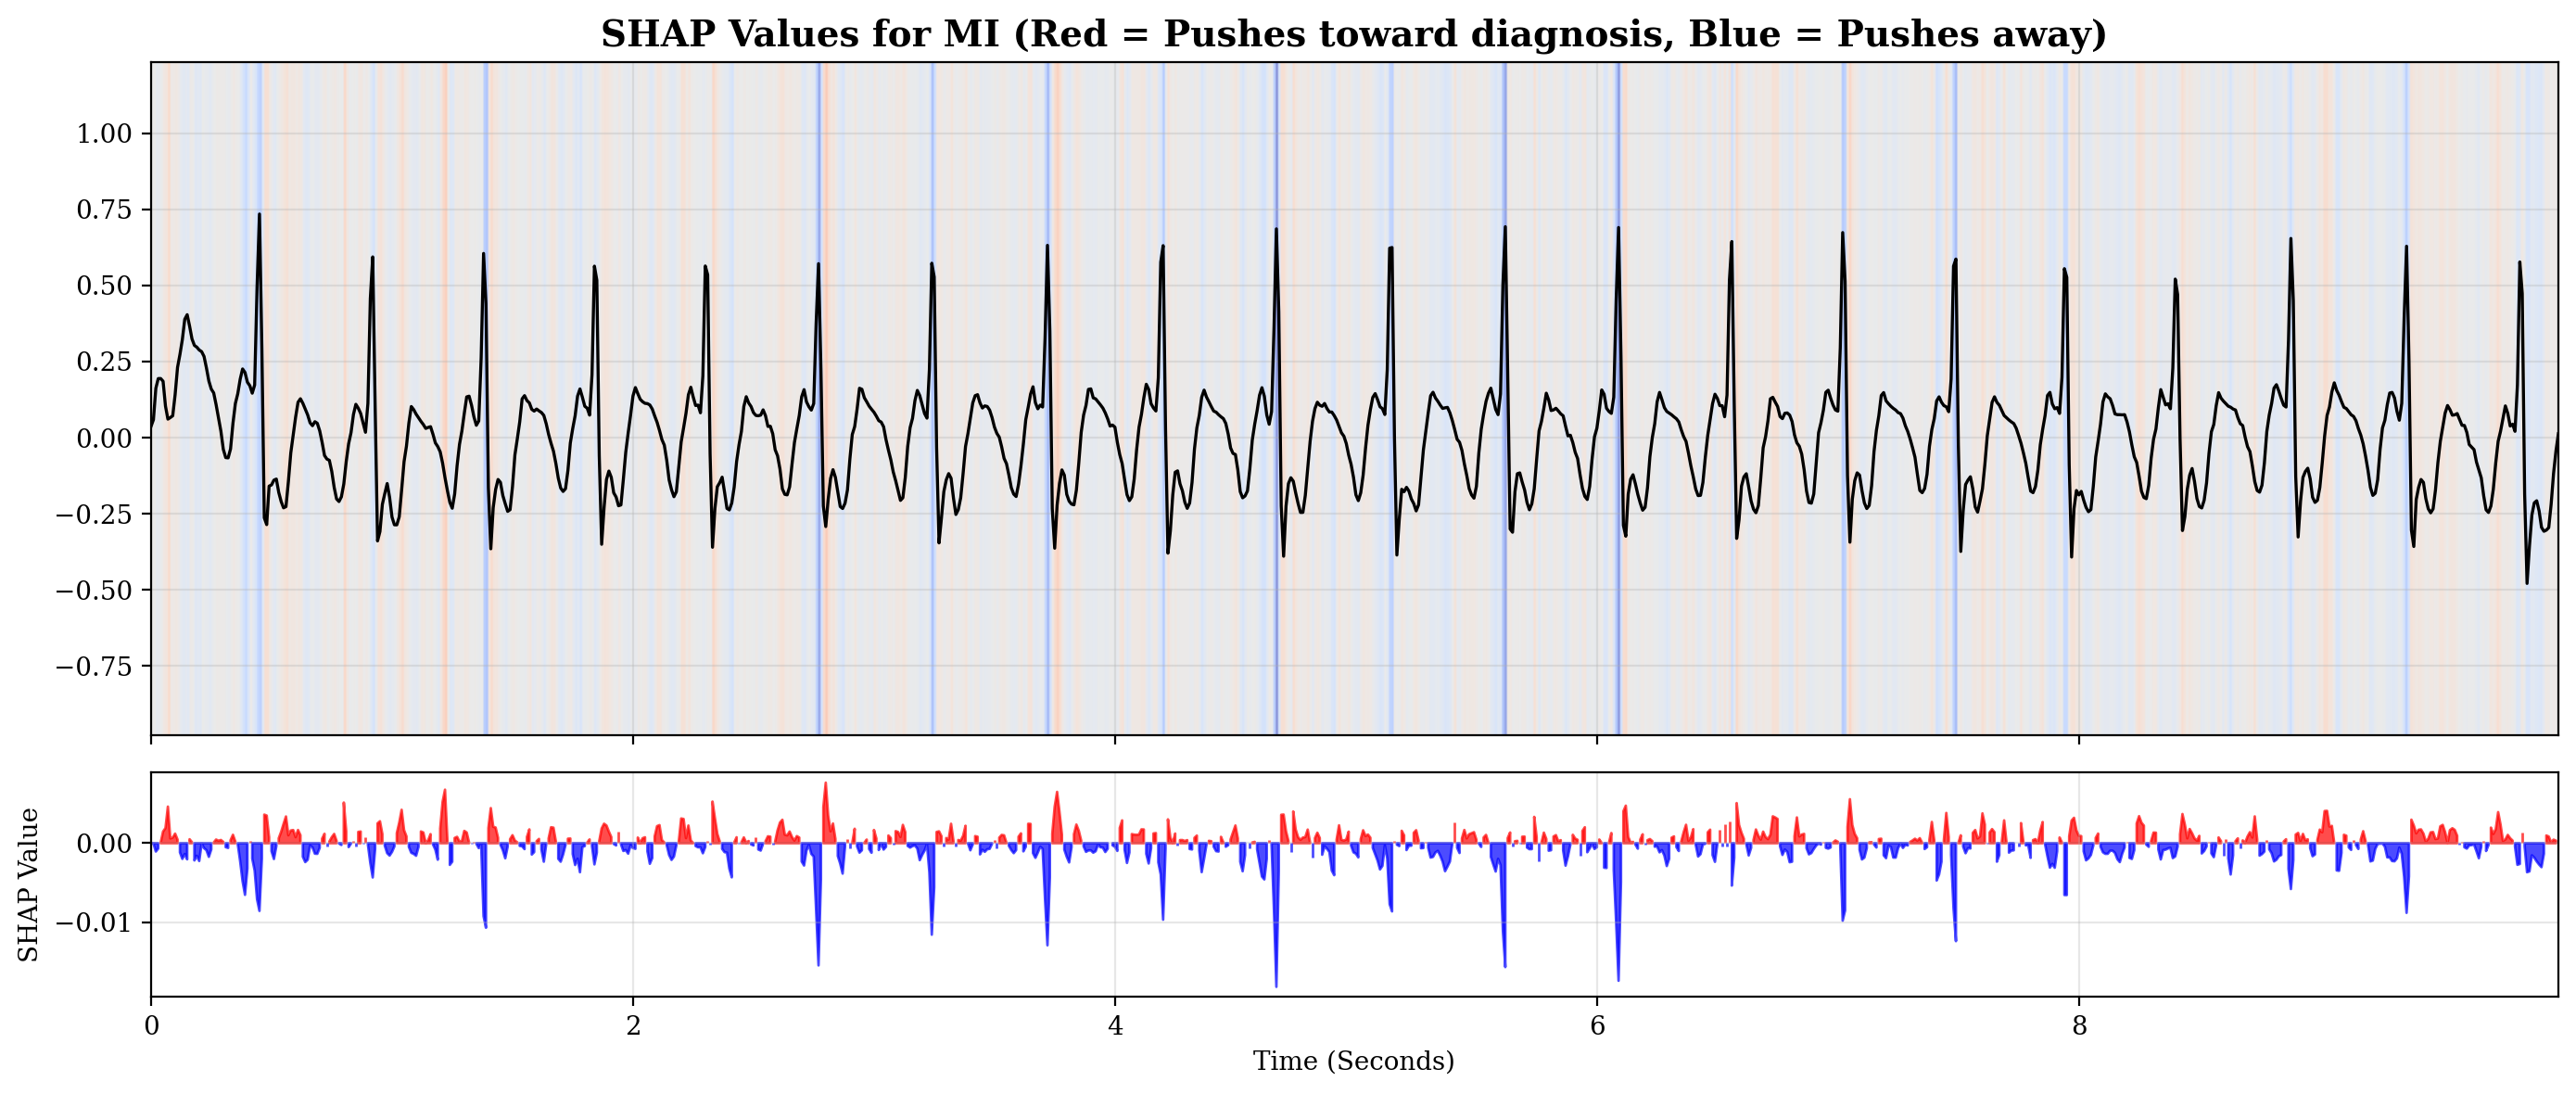

In [ ]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()


background_batch_x, _ = next(iter(train_loader))
background_batch_x = background_batch_x.to(device)
explainer = shap.DeepExplainer(model, background_batch_x)


patient_tensor, patient_label = val_dataset[5]
patient_tensor = patient_tensor.unsqueeze(0).to(device)


shap_values = explainer.shap_values(patient_tensor, check_additivity=False)

def plot_shap_1d(patient_tensor, shap_values, target_class_idx, lead_idx=1, class_name="MI"):

    original_signal = patient_tensor.cpu().squeeze()[lead_idx].numpy()
    lead_shap_values = shap_values[0][lead_idx][:, target_class_idx]

    time = np.arange(1000) / 100.0

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    fig.patch.set_facecolor('#ffffff')
    ax1.set_facecolor('#ffffff')
    ax1.plot(time, original_signal, color='black', linewidth=1.2, zorder=2)

    max_abs_shap = np.max(np.abs(lead_shap_values)) + 1e-8
    extent = [time[0], time[-1], original_signal.min() - 0.5, original_signal.max() + 0.5]
    ax1.imshow(lead_shap_values[np.newaxis, :], cmap='coolwarm', aspect='auto',
               alpha=0.6, extent=extent, zorder=1, vmin=-max_abs_shap, vmax=max_abs_shap)

    ax1.set_title(f"SHAP Values for {class_name} (Red = Pushes toward diagnosis, Blue = Pushes away)",
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.set_facecolor('#ffffff')
    ax2.fill_between(time, 0, lead_shap_values, where=(lead_shap_values > 0), color='red', alpha=0.7)
    ax2.fill_between(time, 0, lead_shap_values, where=(lead_shap_values < 0), color='blue', alpha=0.7)
    ax2.set_ylabel("SHAP Value")
    ax2.set_xlabel("Time (Seconds)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_shap_1d(patient_tensor, shap_values, target_class_idx=1, lead_idx=1, class_name="MI")

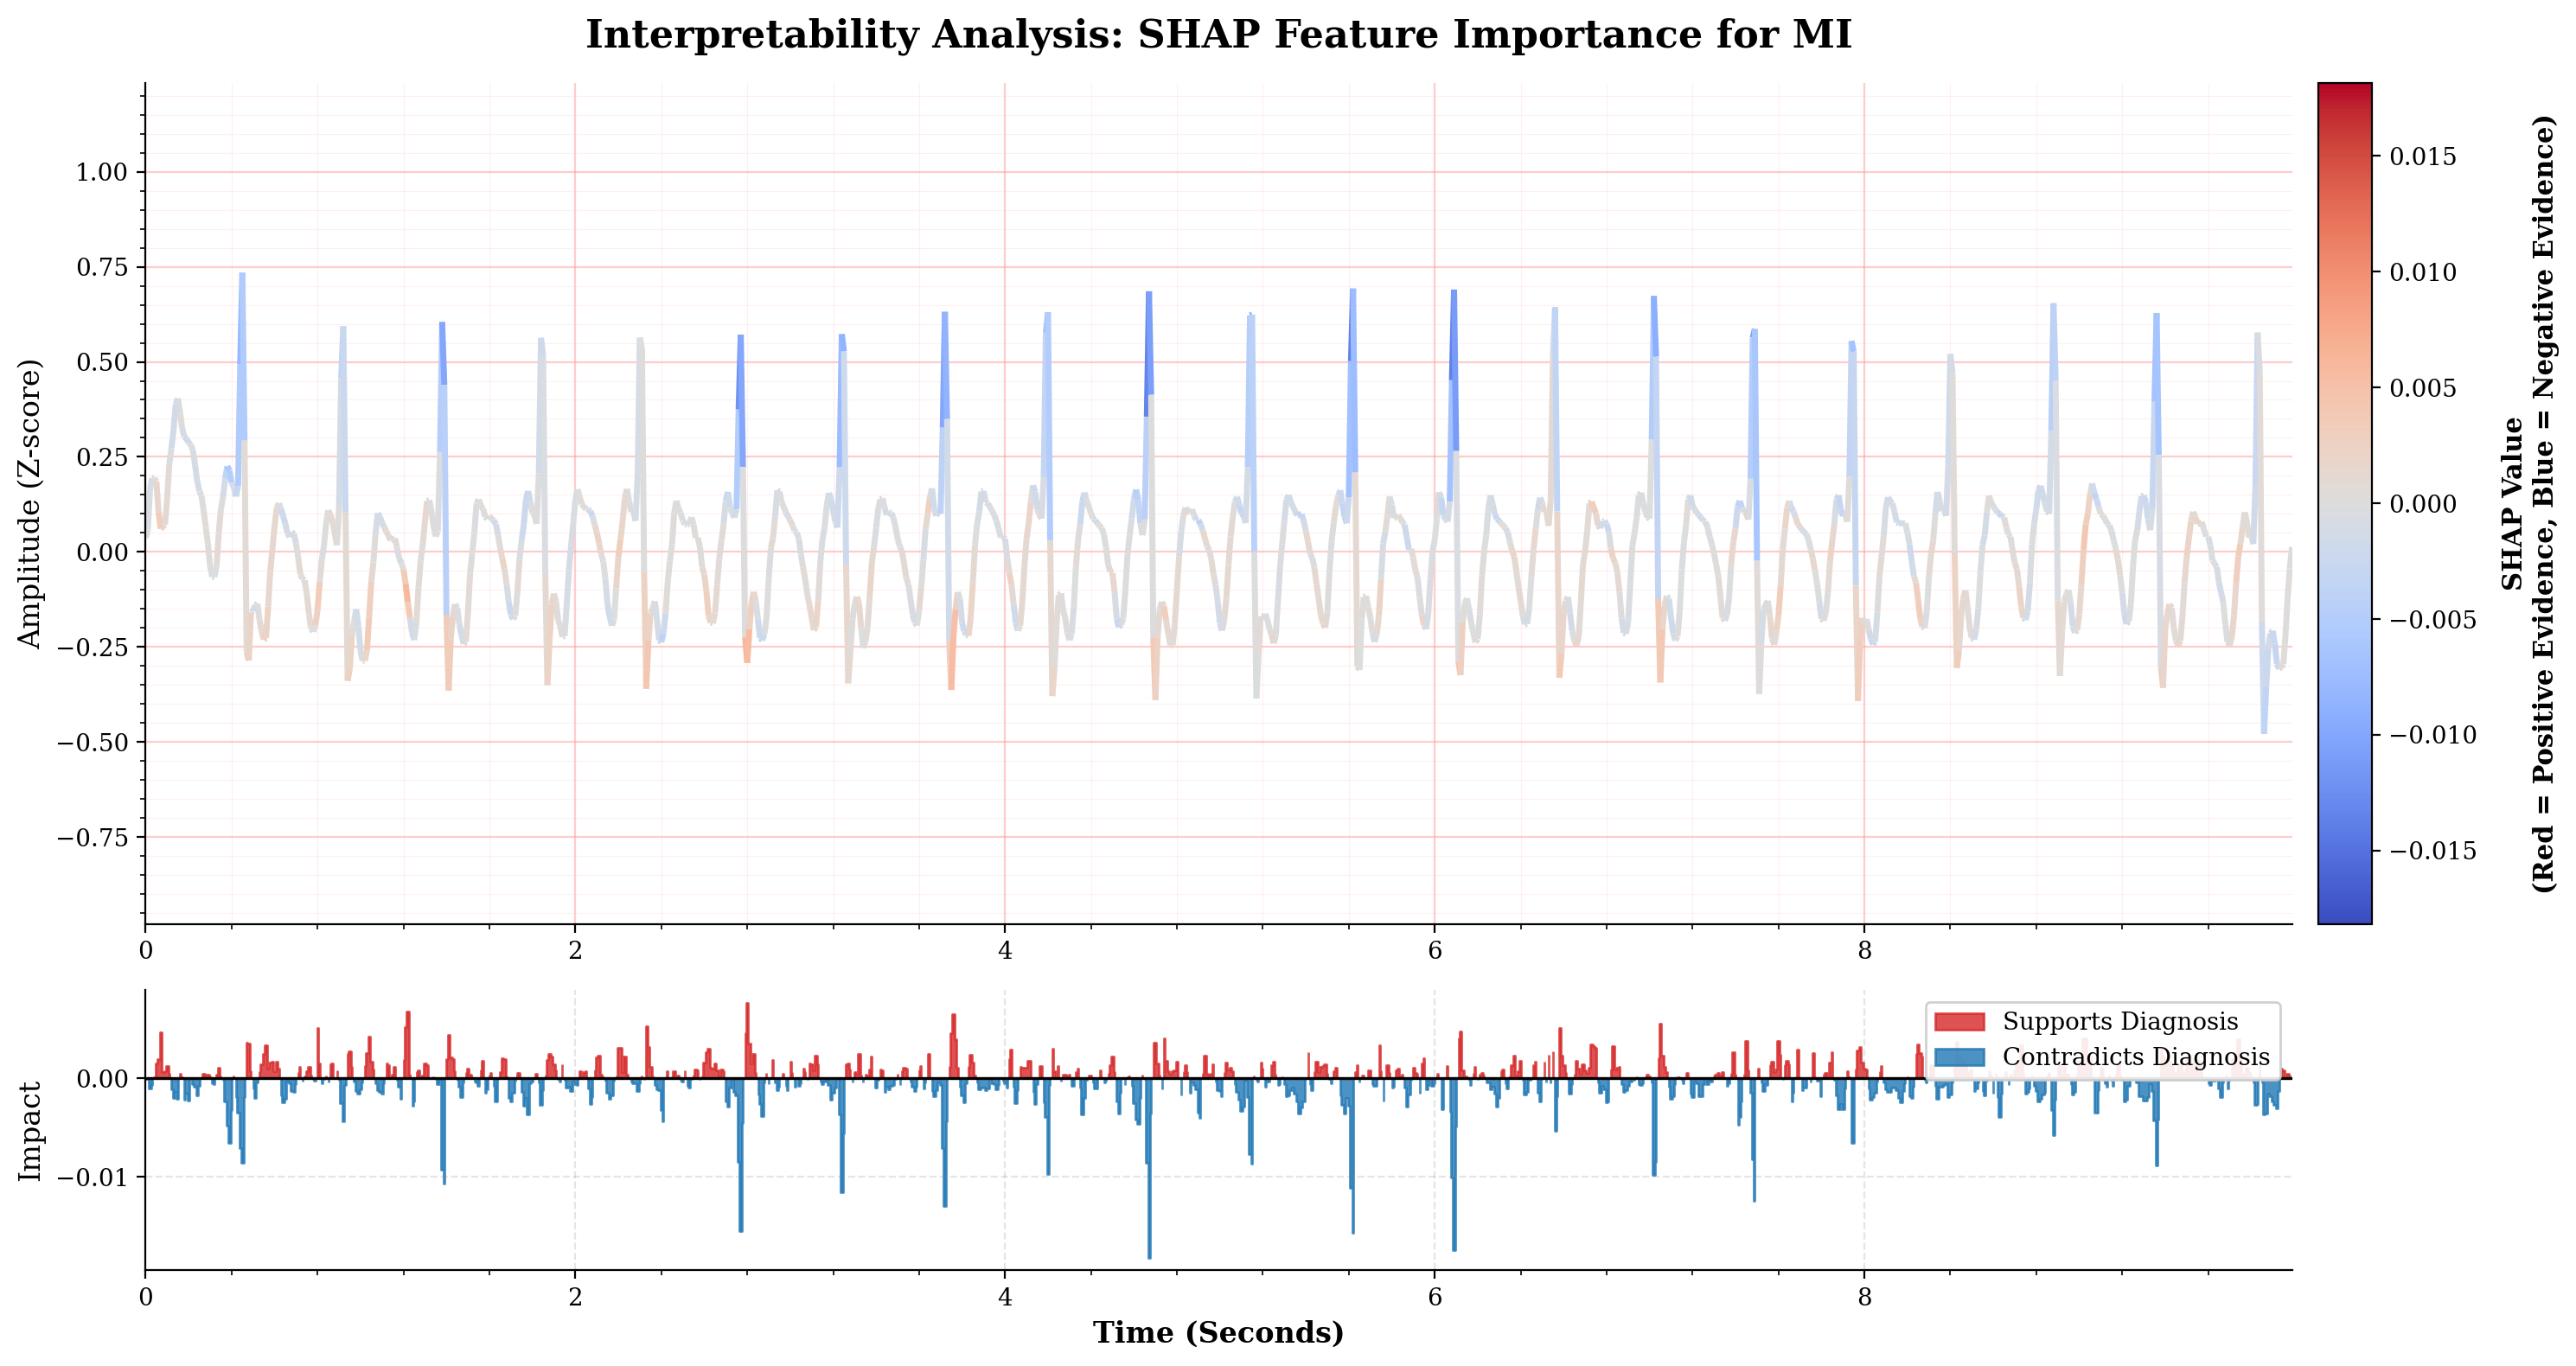

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import AutoMinorLocator

def plot_shap_1d_advanced(patient_tensor, shap_values, target_class_idx, lead_idx=1, class_name="MI"):

    original_signal = patient_tensor.cpu().squeeze()[lead_idx].numpy()
    lead_shap_values = shap_values[0][lead_idx][:, target_class_idx]

    time = np.arange(1000) / 100.0
    fig = plt.figure(figsize=(15, 8))
    fig.patch.set_facecolor('#ffffff')
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[40, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    cax = fig.add_subplot(gs[0, 1])

    max_abs_shap = np.max(np.abs(lead_shap_values)) + 1e-8

    ax1.set_facecolor('#ffffff')


    points = np.array([time, original_signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    shap_segments = (lead_shap_values[:-1] + lead_shap_values[1:]) / 2

    norm = plt.Normalize(vmin=-max_abs_shap, vmax=max_abs_shap)
    lc = LineCollection(segments, cmap='coolwarm', norm=norm)
    lc.set_array(shap_segments)
    lc.set_linewidth(2.5)

    line = ax1.add_collection(lc)
    ax1.set_xlim(time.min(), time.max())
    ax1.set_ylim(original_signal.min() - 0.5, original_signal.max() + 0.5)

    ax1.set_title(f"Interpretability Analysis: SHAP Feature Importance for {class_name}",
                  fontsize=16, fontweight='bold', pad=15)
    ax1.set_ylabel("Amplitude (Z-score)", fontsize=12)

    ax1.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax1.grid(True, which='major', color='#ff9999', alpha=0.5, linewidth=0.8)
    ax1.grid(True, which='minor', color='#ffcccc', alpha=0.3, linewidth=0.4)

    cbar = fig.colorbar(line, cax=cax)
    cbar.set_label('SHAP Value\n(Red = Positive Evidence, Blue = Negative Evidence)',
                   fontsize=11, fontweight='bold', labelpad=10)

    ax2.set_facecolor('#ffffff')

    ax2.axhline(0, color='black', linewidth=1.2, linestyle='-')

    ax2.fill_between(time, 0, lead_shap_values, where=(lead_shap_values > 0),
                     color='#d62728', alpha=0.8, step='mid', label='Supports Diagnosis')
    ax2.fill_between(time, 0, lead_shap_values, where=(lead_shap_values < 0),
                     color='#1f77b4', alpha=0.8, step='mid', label='Contradicts Diagnosis')

    ax2.set_ylabel("Impact", fontsize=12)
    ax2.set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')

    ax2.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax2.grid(True, which='major', color='gray', alpha=0.2, linestyle='--')
    ax2.legend(loc='upper right', fontsize=10, framealpha=0.9)


    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_shap_1d_advanced(patient_tensor, shap_values, target_class_idx=1, lead_idx=1, class_name="MI")

# 2-IG

In [ ]:
!pip install captum

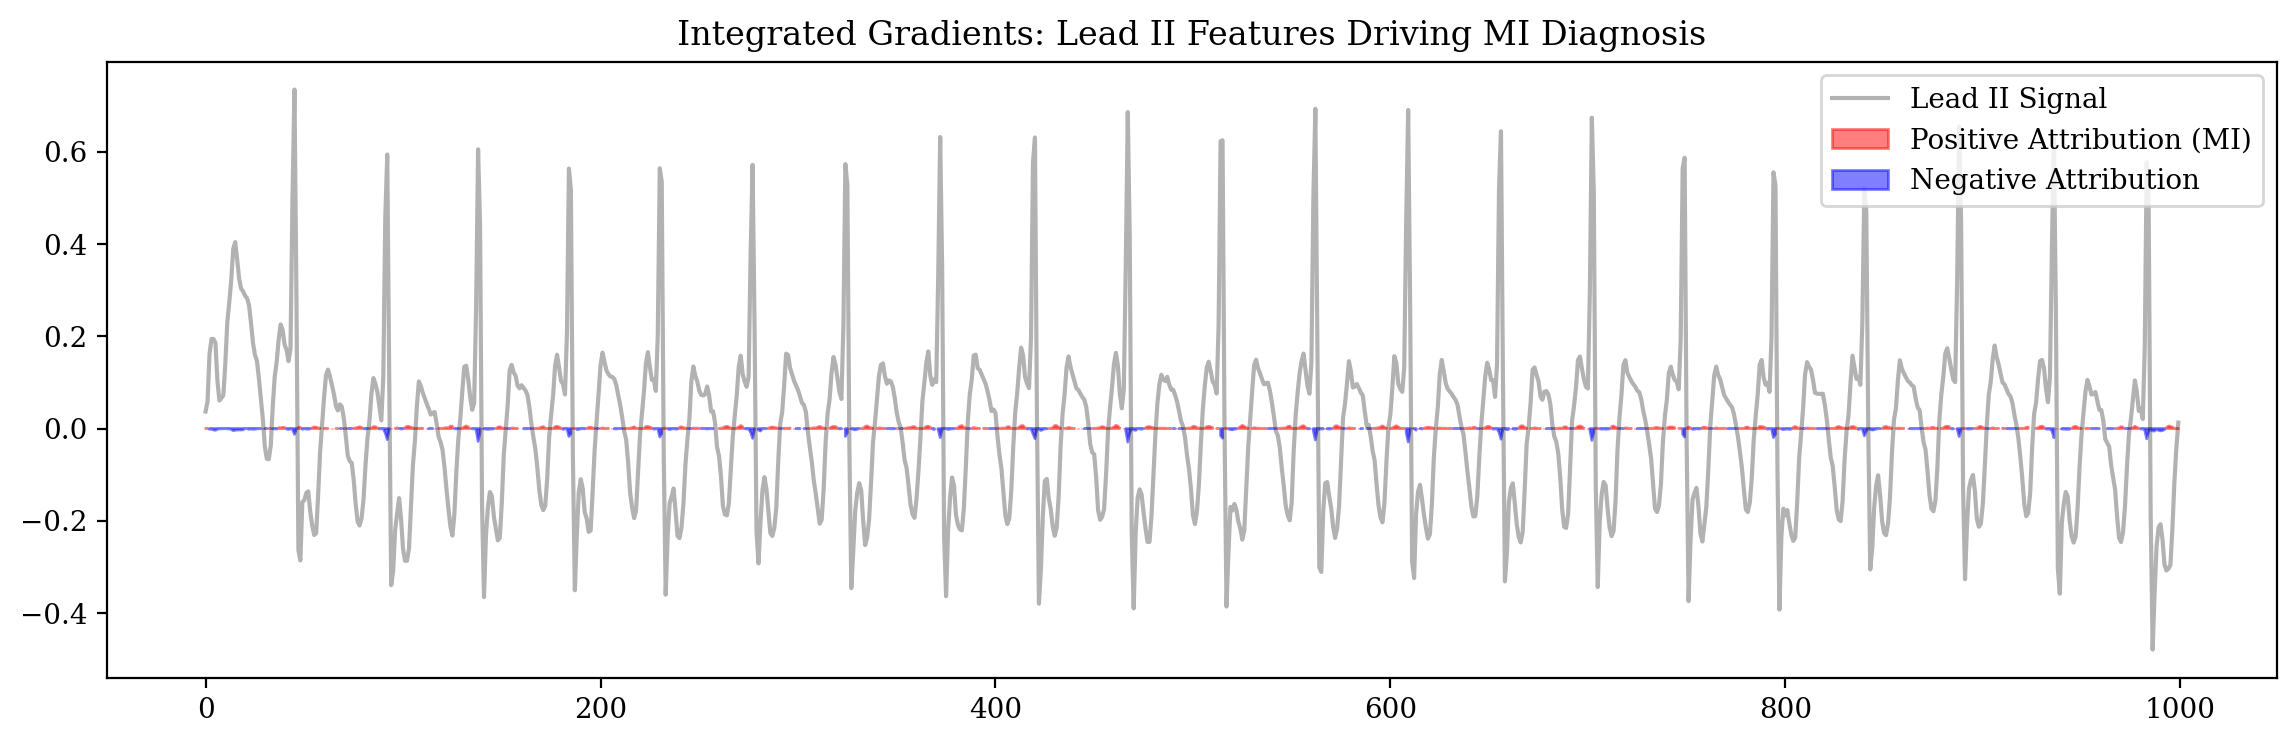

In [ ]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)
attr_ig, delta = ig.attribute(patient_tensor, target=1, n_steps=50, return_convergence_delta=True)
attr_ig_np = attr_ig.squeeze().cpu().detach().numpy()[1]
signal_np = patient_tensor.squeeze().cpu().detach().numpy()[1]

plt.figure(figsize=(14, 4))
plt.plot(signal_np, color='black', alpha=0.3, label='Lead II Signal')
plt.fill_between(range(1000), 0, attr_ig_np, where=attr_ig_np > 0, color='red', alpha=0.5, label='Positive Attribution (MI)')
plt.fill_between(range(1000), 0, attr_ig_np, where=attr_ig_np < 0, color='blue', alpha=0.5, label='Negative Attribution')
plt.title("Integrated Gradients: Lead II Features Driving MI Diagnosis")
plt.legend()
plt.show()

# 3-Grad-CAM

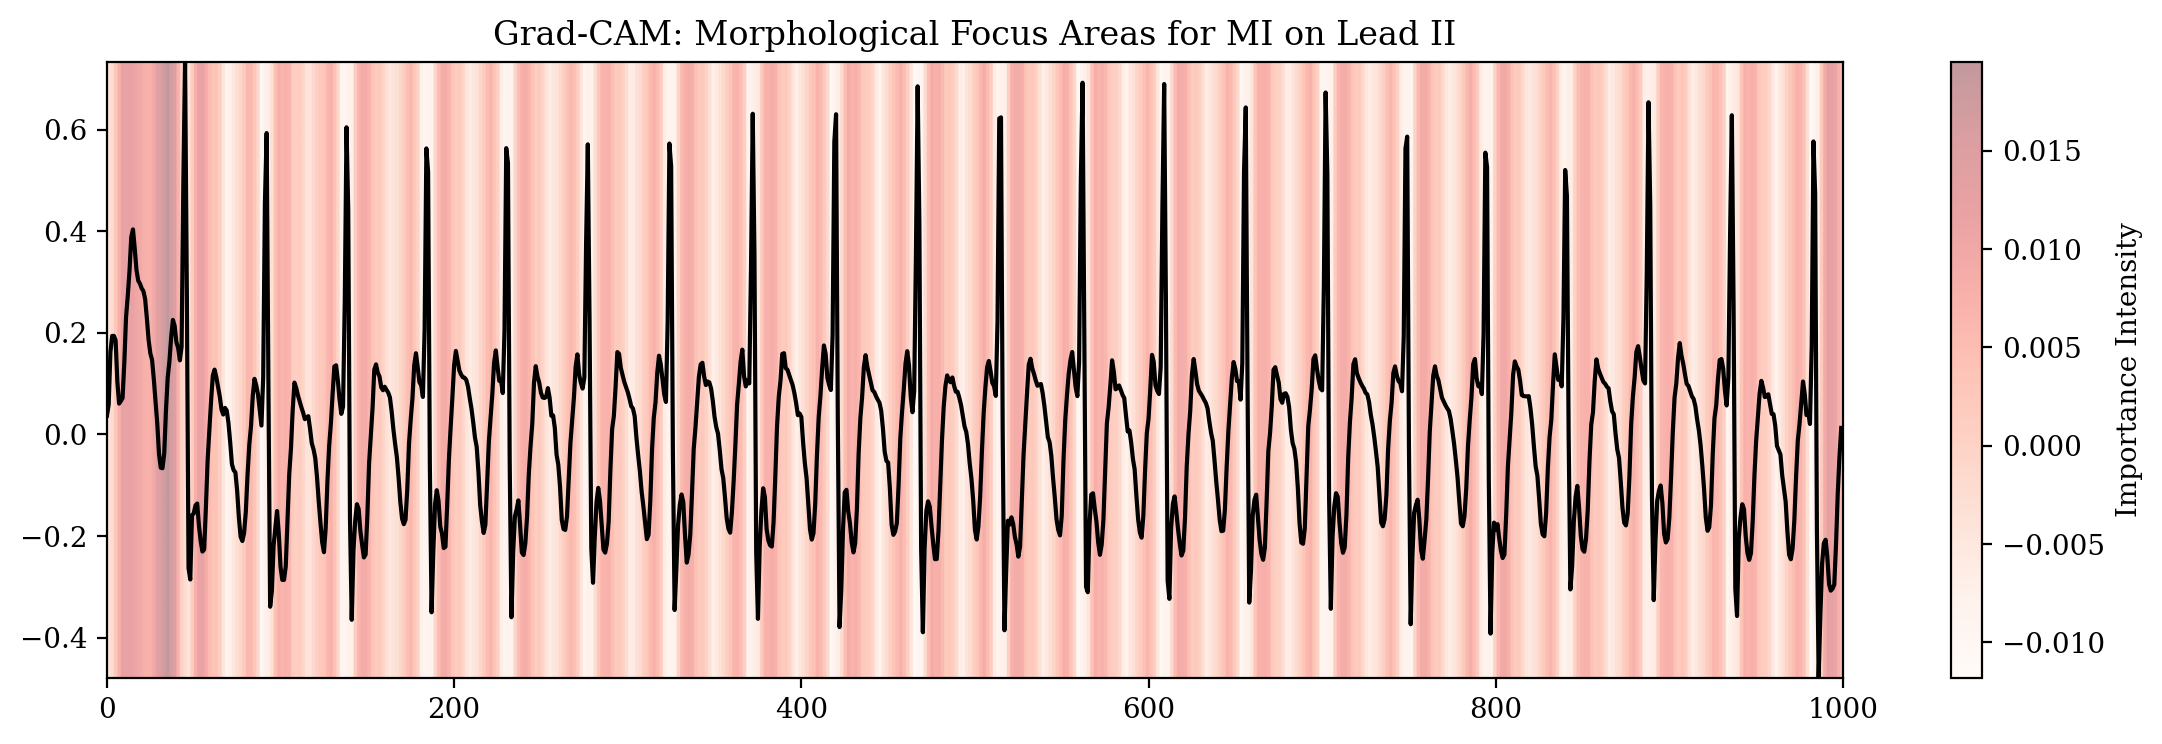

In [ ]:
from captum.attr import LayerGradCam

lgc = LayerGradCam(model, model.block2)

attr_lgc = lgc.attribute(patient_tensor, target=1)
attr_lgc_upsampled = LayerGradCam.interpolate(attr_lgc, (1000,))

attr_lgc_np = attr_lgc_upsampled.squeeze().cpu().detach().numpy()

plt.figure(figsize=(14, 4))
plt.plot(signal_np, color='black', label='Lead II Signal')

plt.imshow(attr_lgc_np[np.newaxis, :], cmap='Reds', aspect='auto',
           alpha=0.4, extent=[0, 1000, signal_np.min(), signal_np.max()])
plt.title("Grad-CAM: Morphological Focus Areas for MI on Lead II")
plt.colorbar(label="Importance Intensity")
plt.show()

# 4-Occlusion

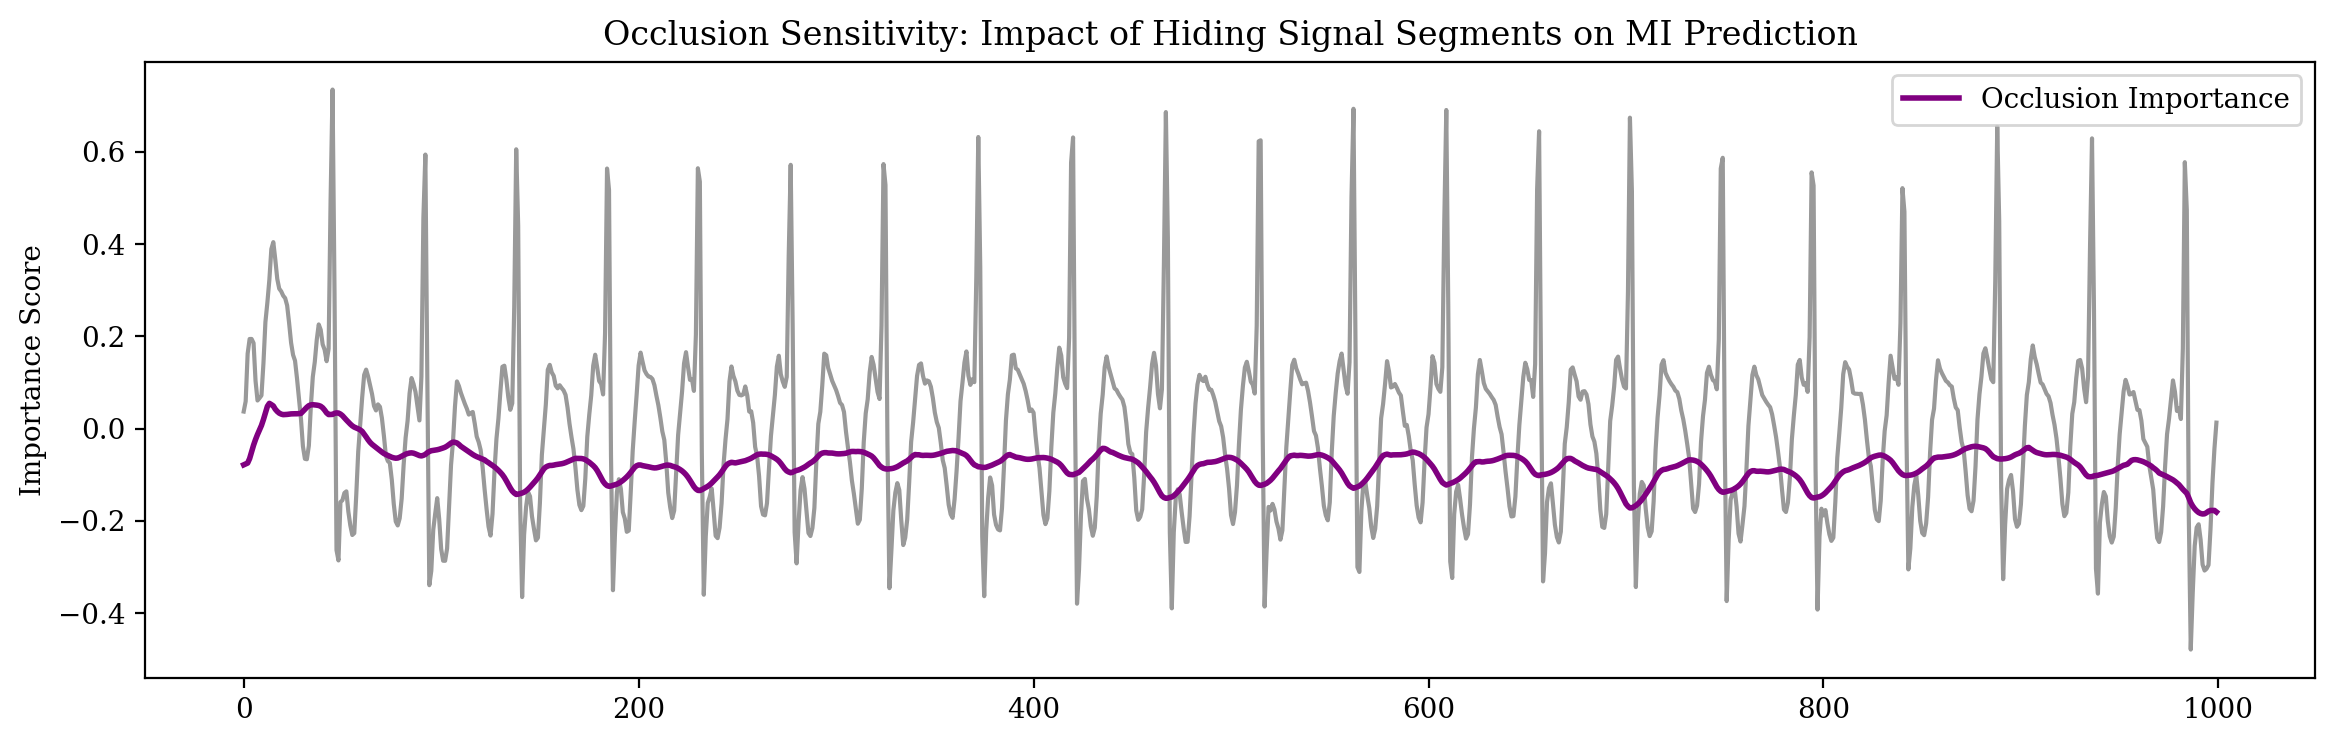

In [ ]:
from captum.attr import Occlusion

occ = Occlusion(model)


attributions_occ = occ.attribute(patient_tensor,
                                 target=1,
                                 sliding_window_shapes=(12, 30),
                                 baselines=0)

attr_occ_np = attributions_occ.squeeze().cpu().detach().numpy()[1]

plt.figure(figsize=(14, 4))
plt.plot(signal_np, color='black', alpha=0.4)
plt.plot(attr_occ_np, color='purple', linewidth=2, label='Occlusion Importance')
plt.title("Occlusion Sensitivity: Impact of Hiding Signal Segments on MI Prediction")
plt.ylabel("Importance Score")
plt.legend()
plt.show()